# =============================== # Modelling Notebook # ===============================

In [2]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd().resolve()

if "jupyter" in str(BASE_DIR).lower():
    BASE_DIR = BASE_DIR.parent

SRC_PATH = BASE_DIR / "src"

sys.path.insert(0, str(SRC_PATH))

print("BASE_DIR:", BASE_DIR)
print("SRC_PATH:", SRC_PATH)
print("models exists:", (SRC_PATH / "models").exists())

BASE_DIR: C:\Users\david\Portfolio 5\heritage-housing
SRC_PATH: C:\Users\david\Portfolio 5\heritage-housing\src
models exists: True


## Objectives

- Fit and evaluate regression models to predict SalePrice.
- Apply feature engineering pipeline developed earlier.
- Compare candidate regression models using cross-validation.
- Select best model and optimise hyperparameters.
- Export final train/test sets, pipelines, and feature importance plot.


## Inputs 
- outputs/datasets/processed/TrainSet.csv
- outputs/datasets/processed/TestSet.csv

## Outputs
- Train set (features and target)
- Test set (features and target)
- Modeling pipeline
- Feature importance plot

### Import Cell

In [3]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from models.evaluation import evaluate_regression, plot_predictions, plot_residuals
from models.model_selection import HyperparameterOptimizationSearch
from models.pipeline import build_final_pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


---

## Change working directory

We need to set the current working directory to the parent folder for consistency.

Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\david\\Portfolio 5\\heritage-housing\\jupyter_notebooks'

## Load Cleaned Data and Split into Trained and Test Sets



In [5]:
# Load data
train_path = BASE_DIR / "outputs/datasets/processed/TrainSet.csv"
test_path = BASE_DIR / "outputs/datasets/processed/TestSet.csv"

TrainSet = pd.read_csv(train_path)
TestSet = pd.read_csv(test_path)

target = "SalePrice"

X_train = TrainSet.drop(columns=[target])
y_train = TrainSet[target]

X_test = TestSet.drop(columns=[target])
y_test = TestSet[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 30)
Test shape: (292, 30)


---

# ===============================
## Model Pipeline
# ===============================

### Model Benchmarking

#### Define Candidate Models

In [6]:
models_quick_search = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

### Define Hyperparameter Grids (Baseline)

In [7]:
params_quick_search = {
    "LinearRegression": {},
    "Ridge": {},
    "Lasso": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "XGBRegressor": {}
}

### Run GridSearchCV (Quick Benchmark)

#### Custom class for Hyperparameter Optimization

In [8]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [9]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)


Running GridSearchCV for LinearRegression

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for Ridge

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for Lasso

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.344e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.344e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(



Running GridSearchCV for RandomForestRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor

Fitting 5 folds for each of 1 candidates, totalling 5 fits


### Evaluate Model Performance

In [10]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
4,GradientBoostingRegressor,-22748.616237,-21007.339918,-19266.063600,1741.276318
3,RandomForestRegressor,-23454.130783,-21326.009354,-19197.887925,2128.121429
2,Lasso,-23413.222677,-21971.710865,-20530.199052,1441.511813
5,ExtraTreesRegressor,-23844.863705,-22295.876948,-20746.890192,1548.986757
1,Ridge,-24780.652623,-23065.884404,-21351.116186,1714.768219
6,XGBRegressor,-27062.547686,-24461.834945,-21861.122203,2600.712741
0,LinearRegression,-49190.228494,-47249.666175,-45309.103857,1940.562318


### Select Best Performing Model

In [11]:
best_model = grid_search_summary.iloc[0, 0]
best_model

'GradientBoostingRegressor'

#### Model Selection for Hyperparameter Optimisation

Based on baseline model evaluation using cross-validation, GradientBoostingRegressor achieved the best performance (lowest MAE and good stability across folds).

Therefore, it is selected as the final model for hyperparameter tuning.

### Define Hyperparameter Grid for Best Model

In [12]:
models_search = {
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

params_search = {
    "GradientBoostingRegressor": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.1, 0.01, 0.001],
        "model__max_depth": [3, 5, 10]
    }
}

### Run GridSearchCV (Tuned Model)

In [13]:
search = HyperparameterOptimizationSearch(
    models=models_search,
    params=params_search
)

search.fit(
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)


Running GridSearchCV for GradientBoostingRegressor

Fitting 5 folds for each of 18 candidates, totalling 90 fits


### Evaluate Tuned Model Performance

In [14]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__learning_rate,model__max_depth,model__n_estimators
0,GradientBoostingRegressor,-22748.616237,-21007.339918,-19266.063600,1741.276318,0.100,3,100
2,GradientBoostingRegressor,-23348.618858,-21278.684240,-19208.749621,2069.934618,0.100,5,100
1,GradientBoostingRegressor,-22863.247022,-21303.961352,-19744.675682,1559.285670,0.100,3,300
9,GradientBoostingRegressor,-23334.011914,-21524.676760,-19715.341607,1809.335153,0.010,5,300
3,GradientBoostingRegressor,-23566.664785,-21628.180930,-19689.697075,1938.483855,0.100,5,300
7,GradientBoostingRegressor,-24655.343628,-22574.982913,-20494.622198,2080.360715,0.010,3,300
4,GradientBoostingRegressor,-25666.080336,-24434.554733,-23203.029131,1231.525603,0.100,10,100
5,GradientBoostingRegressor,-25677.524429,-24441.214277,-23204.904125,1236.310152,0.100,10,300
11,GradientBoostingRegressor,-25700.256689,-24591.076472,-23481.896256,1109.180216,0.010,10,300
8,GradientBoostingRegressor,-32168.176775,-30029.875206,-27891.573638,2138.301569,0.010,5,100


### Extract Best Model Pipeline

In [15]:
best_model_name = grid_search_summary.iloc[0, 0]
pipeline_reg = grid_search_pipelines[best_model_name].best_estimator_
best_params = grid_search_pipelines[best_model_name].best_params_

pipeline_reg


Pipeline(steps=[('scaler', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=GradientBoostingRegressor(random_state=42))),
                ('model', GradientBoostingRegressor(random_state=42))])

## Model Evaluation 

In [16]:
train_metrics = evaluate_regression(X_train, y_train, pipeline_reg)
test_metrics = evaluate_regression(X_test, y_test, pipeline_reg)

MAE: 14957.894538981616
RMSE: 20272.04768153568
R2: 0.9311002689161176
MAE: 21702.620233479312
RMSE: 37466.361058645874
R2: 0.81699237124211


#### Model Train Set vs Test Set comparison 
The model achieves strong performance (R²: 0.93 train, 0.82 test) with mild overfitting. Test MAE (~£21.7k) indicates reasonable prediction error, with higher errors likely occurring on extreme property values.

---

### Plot Actual vs Predicted Values

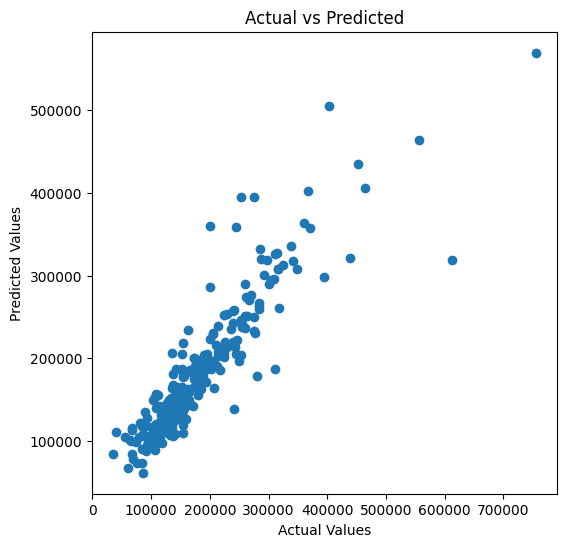

In [17]:
plot_predictions(X_test, y_test, pipeline_reg)

### Plot Residual Distribution

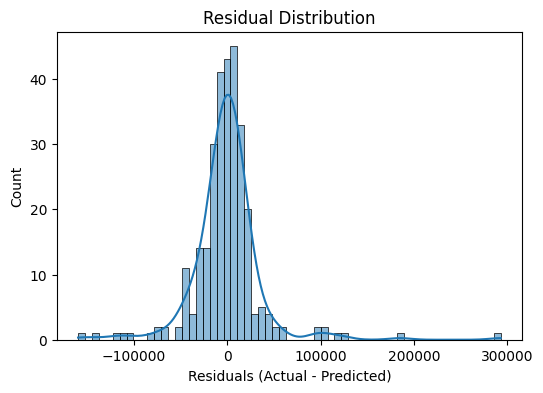

In [18]:
plot_residuals(X_test, y_test, pipeline_reg)

#### Observations from predictions plot

The model demonstrates a strong overall fit, with predictions generally tracking actual values. However, error variance increases with property value, and the model has larger and more frequent deviations for high-priced properties, indicating reduced reliability on extreme values.

### Feature Importance

In [19]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

final_pipeline = build_final_pipeline(
    best_params=best_params,
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['BedroomAbvGr', 'BsmtFinSF1', 'BsmtUnfSF', 'GarageArea', 'GrLivArea',
       'LotArea', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'OverallCond',
       'TotalBsmtSF', 'YearBuilt', 'BsmtExposure_No', 'BsmtExposure_Av',
       'BsmtExposure_Gd', 'BsmtExposure_Mn', 'BsmtExposure_Missing',
       'Bsm...Type1_LwQ',
       'BsmtFinType1_BLQ', 'BsmtFinType1_Missing', 'BsmtFinType1_GLQ',
       'GarageFinish_RFn', 'GarageFinish_Missing', 'GarageFinish_Unf',
       'GarageFinish_Fin', 'KitchenQual_TA', 'KitchenQual_Ex',
       'KitchenQual_Fa'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [20]:
ohe_features = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
model = final_pipeline.named_steps["model"]

df_feature_importance = pd.DataFrame({
    "Feature": ohe_features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Show evidence
display(df_feature_importance.head(10))


,Feature,Importance
4,num__GrLivArea,0.393083
11,num__YearBuilt,0.155152
10,num__TotalBsmtSF,0.104747
3,num__GarageArea,0.103110
1,num__BsmtFinSF1,0.088971
28,num__KitchenQual_Ex,0.049028
27,num__KitchenQual_TA,0.030168
5,num__LotArea,0.026075
9,num__OverallCond,0.013253
8,num__OpenPorchSF,0.007970


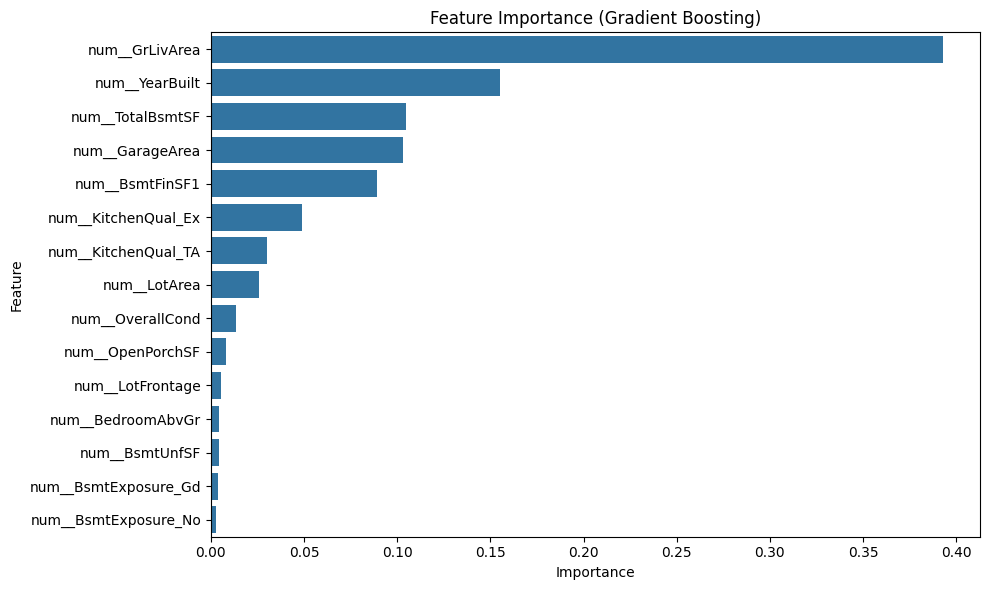

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance (Gradient Boosting)")
plt.tight_layout()
plt.show()

#### Feature Importance Summary

GrLivArea is clearly the dominant predictor, followed by YearBuilt, with TotalBsmtSF, GarageArea, and BsmtFinSF1 contributing moderately. KitchenQual_Ex has minimal impact, indicating the model is driven mainly by size and construction features.




### Final Production Pipeline

#### Define Feature Groups

#### Preprocessing Pipeline

#### Final Pipeline Model 

This pipeline uses a ColumnTransformer to apply scaling to numerical features and one-hot encoding to categorical features. This approach ensures preprocessing is performed consistently during both training and inference, improving deployment reliability and reproducibility.

#### Fit Properly and Evaluate

In [22]:
from src.models.pipeline import build_final_pipeline
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

final_pipeline = build_final_pipeline(
    best_params=best_params,
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

final_pipeline.fit(X_train, y_train)
evaluate_regression(X_test, y_test, final_pipeline)

MAE: 18135.699387709337
RMSE: 32338.041817908263
R2: 0.8636630411315607


(18135.699387709337, 32338.041817908263, 0.8636630411315607)

### Push Files to Repo

#### Create Export Directory

In [23]:
version = "v1_gb_final"
file_path = BASE_DIR / f"outputs/ml_pipeline/predict_saleprice/{version}"
os.makedirs(file_path, exist_ok=True)

#### Export Data Sets

In [24]:
X_train.to_csv(file_path / "X_train.csv", index=False)
y_train.to_csv(file_path / "y_train.csv", index=False)

X_test.to_csv(file_path / "X_test.csv", index=False)
y_test.to_csv(file_path / "y_test.csv", index=False)

#### Export Trained Model Pipeline

In [25]:
# Export Trained Model Pipeline
joblib.dump(final_pipeline, file_path / "model_pipeline.pkl")

# Export feature list used for training
joblib.dump(X_train.columns.tolist(), file_path / "feature_list.pkl")

['C:\\Users\\david\\Portfolio 5\\heritage-housing\\outputs\\ml_pipeline\\predict_saleprice\\v1_gb_final\\feature_list.pkl']

### Final Model Summary

In [26]:
final_summary = grid_search_summary.iloc[0]
final_summary

estimator               GradientBoostingRegressor
min_score                           -22748.616237
mean_score                          -21007.339918
max_score                             -19266.0636
std_score                             1741.276318
model__learning_rate                          0.1
model__max_depth                                3
model__n_estimators                           100
Name: 0, dtype: object